# Choosing a model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/choosing_a_model.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/choosing_a_model.ipynb)

Every model in `lazy` takes the same parameters and gives the same outputs,
so comparing them takes a loop over names and nothing else. In this
tutorial, we run TabPFN-3.5, TabPFN-3.5-fast, TabICLv2, LimiX-2 and TabFM on
four regression benchmarks from the literature on probabilistic deep
learning, and we compare their cost and the quality of their predicted
distributions. We then show how a model fits into scikit-learn's tools, and
how a run is made reproducible.

## Setup

On Google Colab, the cell below installs the package with all four
backends. The code of LimiX is not on PyPI, so the `limix` extra installs
only its dependencies, and the second line (commented out) installs the
code itself (see
[Installation](https://lazy-tfm.readthedocs.io/en/latest/installation.html)).
Without it, the loop below skips LimiX-2 with a printed note, and it does
the same for any other model whose package is missing.

The licenses of the weights differ between the models. TabICLv2 is
BSD-licensed, while the weights of TabPFN-3.5, TabPFN-3.5-fast, LimiX-2 and
TabFM are for non-commercial use only (see
[Supported models](https://lazy-tfm.readthedocs.io/en/latest/models/index.html)).

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,tabicl,tabfm,limix]'
    %pip install -q 'LimiX @ git+https://github.com/limix-ldm-ai/LimiX@516bf396333feb3198cf7aff8a6c10421f218e24'
    pass

In [2]:
import time  # Timing

import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables
from sklearn import base as sklearn_base  # clone
from sklearn import model_selection  # Splits and searches

import lazy  # The topic of this tutorial
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # The one constant to rule them all

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## The data

We use four of the UCI regression datasets that have become the standard
benchmark for predictive uncertainty, which `datasets.load_dataset` loads by
name (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
In that literature, these datasets are scored with the negative log
likelihood of the truth (e.g., the deep ensembles of
[Lakshminarayanan et al. 2017](https://arxiv.org/abs/1612.01474)), which we
report below together with the CRPS. To keep the runtime modest, we take at
most 2,000 random rows of each dataset, which affects only `kin8nm` (8,192
rows). We leave out the larger `protein` (45,730 rows), which can be added
to `NAMES` at the cost of a longer run. Each dataset is then split once, at
random, into 90% context and 10% test rows.

In [3]:
NAMES = ["yacht", "energy", "concrete", "kin8nm"]
MAX_ROWS = 2_000

rng = np.random.default_rng(SEED)
splits = {}
for name in NAMES:
    data = datasets.load_dataset(name)
    rows = rng.permutation(len(data))[:MAX_ROWS]
    splits[name] = model_selection.train_test_split(
        data.X.iloc[rows], data.y[rows], test_size=0.1, random_state=SEED
    )
    X_train, X_test = splits[name][:2]
    print(f"{name:>8}: {len(X_train):>5,} context, {len(X_test):>3,} test rows")

   yacht:   277 context,  31 test rows
  energy:   691 context,  77 test rows
concrete:   927 context, 103 test rows
  kin8nm: 1,800 context, 200 test rows


## The models

The five models below differ only in the arguments to `lazy.LazyModel`.
TabFM is by far the slowest of them, so we give it 4 ensemble members
instead of the default 8, which the other models keep. This should save
roughly half of its time, at the cost of a small disadvantage in accuracy.

In [4]:
MODELS = [
    lazy.LazyModel("tabpfn", random_state=SEED),
    lazy.LazyModel("tabpfn", version="v3.5-fast", random_state=SEED),
    lazy.LazyModel("tabicl", random_state=SEED),
    lazy.LazyModel("limix", random_state=SEED),
    lazy.LazyModel("tabfm", n_estimators=4, random_state=SEED),
]

For each dataset and model, we time `fit` and `predict_proba` and score the
densities on a common grid of 1,000 bins that spans the target with a margin
on either side. We report the CRPS, which is in the units of the target, and
the NLL, both lower is better, together with the fraction of test rows whose
truth falls inside the central 68% interval. The truth falls inside that
interval exactly when its PIT (the predicted CDF at the truth) lies between
0.16 and 0.84, so we compute the coverage from the PIT values. Each model
loads its weights (and downloads them on first use) within these calls, so
the times include that loading.

In [5]:
records = []
skipped = set()
for name, (X_train, X_test, y_train, y_test) in splits.items():
    pad = 0.2 * np.ptp(y_train)
    grid = lazy.Grid.linear(y_train.min() - pad, y_train.max() + pad, 1000)
    for template in MODELS:
        if template.name_ in skipped:
            continue
        model = sklearn_base.clone(template)
        start = time.perf_counter()
        try:
            model.fit(X_train, y_train)
        except ImportError as error:
            print(f"Skipping {model.name_}: {error}")
            skipped.add(model.name_)
            continue
        fitted = time.perf_counter()
        pdfs = model.predict_proba(X_test, grid)
        predicted = time.perf_counter()
        _, pit = metrics.per_object_scores(y_test, grid, pdfs)
        records.append(
            {
                "dataset": name,
                "model": model.name_,
                "fit [s]": fitted - start,
                "predict [s]": predicted - fitted,
                "CRPS": metrics.crps(y_test, grid, pdfs),
                "NLL": metrics.nll(y_test, grid, pdfs),
                "68% coverage": np.mean((pit >= 0.16) & (pit <= 0.84)),
            }
        )

results = pd.DataFrame(records)
results.set_index(["dataset", "model"]).round(3)

Loading weights from local directory


fit [s]  predict [s]   CRPS    NLL  68% coverage
dataset  model                                                             
yacht    tabpfn:v3.5         2.776        0.190  0.244 -0.388         0.806
         tabpfn:v3.5-fast    0.466        0.053  0.325  0.056         0.806
         tabicl:v2           0.259        0.043  0.277 -0.090         0.677
         limix:v2            2.127        0.358  0.173 -0.217         0.806
         tabfm:v1.0          0.046       11.643  0.631  1.276         0.774
energy   tabpfn:v3.5         1.030        0.153  0.219  0.161         0.688
         tabpfn:v3.5-fast    0.444        0.064  0.224  0.223         0.740
         tabicl:v2           0.298        0.031  0.197  0.226         0.688
         limix:v2            2.113        0.385  0.112 -0.369         0.857
         tabfm:v1.0          0.002        7.745  0.241  0.487         0.740
concrete tabpfn:v3.5         1.098        0.107  1.204  1.724         0.670
         tabpfn:v3.5-fast    0.476        0.103  1.238  1.870         0.728
         tabicl:v2           0.336        0.032  1.230  2.033         0.767
         limix:v2            2.320        0.428  1.221  1.747         0.631
         tabfm:v1.0          0.002        8.143  1.640  2.973         0.738
kin8nm   tabpfn:v3.5         1.335        0.142  0.044 -1.190         0.695
         tabpfn:v3.5-fast    0.639        0.086  0.048 -1.104         0.620
         tabicl:v2           0.476        0.043  0.047 -1.110         0.670
         limix:v2            3.239        0.606  0.044 -1.180         0.635
         tabfm:v1.0          0.002       11.080  0.046 -1.056         0.640

The table above lists the scores of every model on every dataset. The
figure below shows the CRPS of each model divided by the best CRPS on the
same dataset, so that the best model sits at 1 and the datasets, whose
targets have different units, share one axis.

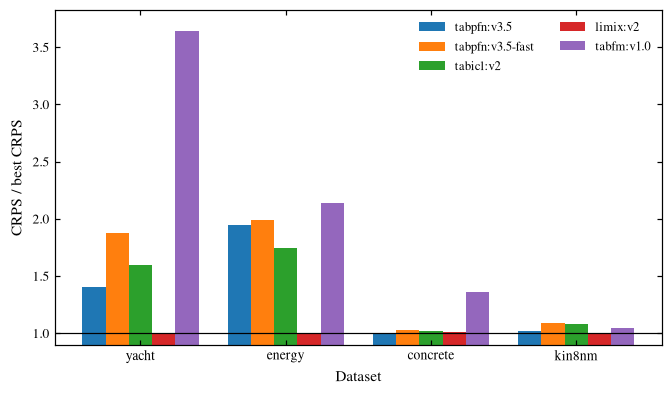

In [6]:
results["CRPS / best"] = results["CRPS"] / results.groupby("dataset")[
    "CRPS"
].transform("min")
table = results.pivot(index="dataset", columns="model", values="CRPS / best")
table = table.loc[NAMES, results["model"].unique()]

fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
width = 0.8 / table.shape[1]
for i, label in enumerate(table.columns):
    x = np.arange(len(table)) + (i - (table.shape[1] - 1) / 2) * width
    ax.bar(x, table[label], width, label=label)
ax.axhline(1, color="k", lw=0.8)
ax.set_xticks(np.arange(len(table)), table.index)
ax.set_ylim(0.9, None)
ax.set_xlabel("Dataset")
ax.set_ylabel("CRPS / best CRPS")
ax.legend(ncols=2, fontsize="small")
plt.show()

The figure shows that no model is the best on every dataset. LimiX-2 has
the lowest CRPS on `yacht`, `energy` and `kin8nm`, and TabPFN-3.5 on
`concrete` (1.204 vs. 1.221 for LimiX-2). The margin is largest on `energy`,
where the other four models have between 1.7 and 2.2 times the CRPS of
LimiX-2 (e.g., 0.219 vs. 0.112 for TabPFN-3.5). On `concrete` and `kin8nm`,
all of the models lie within about 10% of the best, except TabFM on
`concrete`, and on `kin8nm` the CRPS of LimiX-2 and TabPFN-3.5 agree to the
three decimals of the table (0.044). TabFM is the worst on the three smaller
datasets, and the most so on `yacht`, where its CRPS is more than three
times that of LimiX-2 (0.631 vs. 0.173). This might be because its
hierarchy of classifiers over equal-mass bins of the target has few rows per
bin in a context of 277 rows, and because it runs with half as many members
as the others. The 68% coverage lies between 0.620 and 0.857 across the
table. With 31 to 200 test rows per dataset, these fractions are uncertain
by several percentage points, and only LimiX-2 on `energy` (0.857 on 77
rows) stands clearly apart from 0.68.

The times are from this run, on a GPU that was otherwise idle, and they
differ by more than an order of magnitude between the models. TabICLv2 and
TabPFN-3.5-fast are the fastest. LimiX-2 takes longer than TabPFN-3.5 in
`predict_proba` on every dataset and in `fit` on all but `yacht`, where
TabPFN-3.5 is the first model to run and its time likely includes the
start-up of the GPU. TabFM does all of its work in `predict_proba`, where it
takes the longest of all (between 7.7 and 11.6 s). Since these numbers come
from a single random split and a few hundred test rows at most, the
comparison is indicative only. A choice for real work should rest on several
splits of the data at hand, and
[Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html)
gives our recommendations.

## Working with scikit-learn

A `LazyModel` is a scikit-learn estimator. `get_params` lists the
parameters of its backend next to `model` itself, so `clone` (which we used
in the loop above) and the search objects work without prefixes.

In [7]:
params = MODELS[0].get_params()
{key: params[key] for key in ["model", "version", "n_estimators", "bag_size"]}

{'model': 'tabpfn', 'version': 'v3.5', 'n_estimators': 8, 'bag_size': None}

`score` returns the negative CDE loss, so that higher is better, as
scikit-learn's searches assume. We therefore run a small `GridSearchCV` over
the number of ensemble members of TabPFN-3.5, with 3-fold cross-validation
on the context rows of `yacht`, our smallest dataset.

In [8]:
X_train, X_test, y_train, y_test = splits["yacht"]
search = model_selection.GridSearchCV(
    lazy.LazyModel("tabpfn", random_state=SEED),
    {"n_estimators": [4, 8]},
    cv=model_selection.KFold(3, shuffle=True, random_state=SEED),
)
search.fit(X_train, y_train)
pd.DataFrame(search.cv_results_)[
    ["param_n_estimators", "mean_test_score", "std_test_score"]
]

,param_n_estimators,mean_test_score,std_test_score
0,4,3.56385,0.192980
1,8,3.53825,0.292478


The two settings score within each other's spread across the folds (3.564
vs. 3.538, with standard deviations of 0.193 and 0.292), so on 277 rows
the search cannot tell 4 members from 8. It keeps 4, the better of the two
means, and refits that model on all of the context rows.

## Reproducibility

Every model takes `random_state`, the seed of its ensemble, and records
what answered in `provenance_` after `fit`: the pinned checkpoint and its
revision, the versions of the packages and the ensemble recipe (see
[Reproducibility and provenance](https://lazy-tfm.readthedocs.io/en/latest/guide/reproducibility.html)).
We refit the best model of the search with the same seed and check that its
score on the test rows of `yacht` does not change.

In [9]:
best = search.best_estimator_
again = sklearn_base.clone(best).fit(X_train, y_train)
print(best.score(X_test, y_test), again.score(X_test, y_test))
keys = ["backend", "version", "revision", "package", "n_estimators"]
{key: again.provenance_[key] for key in keys + ["random_state"]}

3.635871030832413 3.635871030832413


{'backend': 'tabpfn',
 'version': 'v3.5',
 'revision': '06bf2ba35c80a92a3b9abb436b99cf49e7a0365e',
 'package': 'tabpfn 9.0.0',
 'n_estimators': 4,
 'random_state': 299792458}

The two scores are identical (3.636), since the refit uses the same seed,
context and checkpoint. The cell shows only a few of the entries of
`provenance_`, which also holds the full ensemble recipe and the upstream
configuration that TabPFN ran with. It is a plain dictionary without local
paths, so it can be written out beside the numbers it produced.

For the next steps, we suggest the following pages:

- [Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html):
  which model to choose, and what hardware it needs.
- [Supported models](https://lazy-tfm.readthedocs.io/en/latest/models/index.html):
  the size and license of each model.
- [Scaling and performance](https://lazy-tfm.readthedocs.io/en/latest/guide/scaling.html):
  the measured cost of each model on larger contexts.